# Tarea - 4 - Clasificación Binaria

Utilizando el dataset de fraude, el dueño del banco nos plantea la problemática de identificar a través de un modelo si la transacción es  hecha por una persona "adulta mayor" ( considerar a partir de 50 años ). 

Requisitos de la tarea:
* Subir el archivo .paquet solamente con la TAD. 
* Subir el archivo notebook .ipynb
* La columna con la variable objetivo se debe de llamar "y"
* Las variables finales y mejores para la matriz objetivo deben de tener el prefijo "x_"
* Construir las siguiente variables:
Proporción entre la cantidad de la transacción y la hora del día. ( colocar 0 en caso de ser la primera hora del día).
Proporción entre la cantidad de la transacción y la distancia euclidiana.
Nota importante: No colocar la columna edad ni la columna is_fraud dentro del análisis.


### LIBRERIAS

In [3]:
import pandas as pd
import numpy as np
import os
import gc ##Limpia mi memoria RAM

##ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns


### LECTURA DE DATOS

#### PARTE 1: RECUPERACION DE LOS DATOS


In [30]:
!ls -l


total 4
drwxr-xr-x 9 alex alex 4096 Sep  6 20:53 Modulo1


In [31]:
%cd Modulo1


/home/alex/DiplomadoCD/Modulo1


In [32]:
#variable datos del 2020-2022
path_cov = "2020-2022"

cov_files = os.listdir(path_cov)

cov_files = [ f for f in cov_files if f[:2] == '20' ]

cov_df = []
for id_ in range(len(cov_files )):
    print("Leyendo archivo:", id_ )
    cov_df.append( pd.read_csv(os.path.join( path_cov ,cov_files[id_] )) )

Leyendo archivo: 0
ERROR! Session/line number was not unique in database. History logging moved to new session 17
Leyendo archivo: 1
Leyendo archivo: 2
Leyendo archivo: 3
Leyendo archivo: 4
Leyendo archivo: 5
Leyendo archivo: 6
Leyendo archivo: 7
Leyendo archivo: 8
Leyendo archivo: 9
Leyendo archivo: 10
Leyendo archivo: 11
Leyendo archivo: 12
Leyendo archivo: 13
Leyendo archivo: 14


/tmp/ipykernel_23400/868620746.py:11: DtypeWarning: Columns (0: Ciclo_Estacion_Retiro, 1: Ciclo_EstacionArribo) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df.append( pd.read_csv(os.path.join( path_cov ,cov_files[id_] )) )


Leyendo archivo: 15
Leyendo archivo: 16
Leyendo archivo: 17
Leyendo archivo: 18
Leyendo archivo: 19
Leyendo archivo: 20


/tmp/ipykernel_23400/868620746.py:11: DtypeWarning: Columns (0: Bici) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df.append( pd.read_csv(os.path.join( path_cov ,cov_files[id_] )) )


Leyendo archivo: 21
Leyendo archivo: 22
Leyendo archivo: 23
Leyendo archivo: 24
Leyendo archivo: 25
Leyendo archivo: 26
Leyendo archivo: 27
Leyendo archivo: 28
Leyendo archivo: 29
Leyendo archivo: 30
Leyendo archivo: 31
Leyendo archivo: 32
Leyendo archivo: 33
Leyendo archivo: 34
Leyendo archivo: 35


In [33]:
df_cov = pd.concat( cov_df , ignore_index=True)

In [34]:
df_cov

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha Arribo,Hora_Arribo,Ciclo_Estacion_Arribo,...,Hora_Retiro.1,Genero_usuario,Edad_usuario,CE_retiro,Fecha_retiro,Hora_retiro,CE_arribo,Fecha_arribo,Hora_arribo,BikeID
0,M,63.0,8642,47,31/08/2021,23:51:30,145,01/09/2021,00:00:36,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M,45.0,9389,138,01/09/2021,00:02:43,124,01/09/2021,00:06:26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,36.0,10279,65,31/08/2021,23:27:14,66,01/09/2021,00:10:04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M,49.0,12418,8,31/08/2021,23:18:30,143,01/09/2021,00:17:52,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M,24.0,8732,10,31/08/2021,23:51:29,124,01/09/2021,00:17:55,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13552327,M,32.0,8542.0,334.0,30/07/2022,16:37:53,NaN,NaN,16:52:17,171.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13552328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02:08:26,233.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13552329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15:42:23,225.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13552330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04:30:02,176.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
#Como borrar memoria
del cov_df
import gc
gc.collect()

192

Bola estadistica

In [36]:
df_muestra = df_cov.sample(frac=0.10, random_state=42)

# Limpaimos RAM
del df_cov
gc.collect()

df_cov = df_muestra

print(f"Tamaño de la bola estadistica: {len(df_cov)} filas")

Tamaño de la bola estadistica: 1355233 filas


LIMPIEZA

In [37]:
### UNIFICACIoN DE DATOS FRAGMENTADOS ###

# 1. Genero y Edad
df_cov['Genero_Clean'] = df_cov['Genero_Usuario'].combine_first(df_cov['Genero_usuario'])
df_cov['Edad_Clean'] = df_cov['Edad_Usuario'].combine_first(df_cov['Edad_usuario'])

# 2. ID de Bici y Estaciones
df_cov['Bici_Clean'] = df_cov['Bici'].combine_first(df_cov['BikeID'])
df_cov['Estacion_Retiro_Clean'] = df_cov['Ciclo_Estacion_Retiro'].combine_first(df_cov['CE_retiro'])
df_cov['Estacion_Arribo_Clean'] = df_cov['Ciclo_Estacion_Arribo'].combine_first(df_cov['Ciclo_EstacionArribo']).combine_first(df_cov['CE_arribo'])

# 3. Fechas y Horas de Retiro
df_cov['Fecha_Retiro_Clean'] = df_cov['Fecha_Retiro'].combine_first(df_cov['Fecha_retiro'])
df_cov['Hora_Retiro_Clean'] = df_cov['Hora_Retiro'].combine_first(df_cov['Hora_retiro']).combine_first(df_cov['Hora_Retiro.1'])

# 4. Fechas y Horas de Arribo
df_cov['Fecha_Arribo_Clean'] = df_cov['Fecha_Arribo'].combine_first(df_cov['Fecha_arribo']).combine_first(df_cov['Fecha Arribo'])
df_cov['Hora_Arribo_Clean'] = df_cov['Hora_Arribo'].combine_first(df_cov['Hora_arribo']).combine_first(df_cov['Hora Arribo'])

In [38]:
# los quedamos con las columnas limpias
columnas_finales = [
    'Bici_Clean', 'Genero_Clean', 'Edad_Clean', 
    'Estacion_Retiro_Clean', 'Fecha_Retiro_Clean', 'Hora_Retiro_Clean',
    'Estacion_Arribo_Clean', 'Fecha_Arribo_Clean', 'Hora_Arribo_Clean'
]

df_limpio = df_cov[columnas_finales].copy()



In [39]:
# Liberamos RAM
del df_cov
import gc
gc.collect()

df_limpio.head()

,Bici_Clean,Genero_Clean,Edad_Clean,Estacion_Retiro_Clean,Fecha_Retiro_Clean,Hora_Retiro_Clean,Estacion_Arribo_Clean,Fecha_Arribo_Clean,Hora_Arribo_Clean
4068347,9922,M,44.0,179,11/05/2022,14:58:48,292.0,11/05/2022,15:04:35
8639679,9494.0,M,31.0,186.0,02/12/2021,09:43:32,161,02/12/2021,09:58:57
9845035,9966.0,F,32.0,371.0,19/02/2022,13:06:00,398.0,19/02/2022,13:18:38
2589392,8820,F,33.0,120,18/10/2021,21:22:52,133,18/10/2021,21:29:00
11488493,7064,M,28.0,462.0,14/08/2020,12:03:34,111.0,14/08/2020,12:22:15


In [40]:
# Antes de borrar nulos
print(f"Filas con nulos: {len(df_limpio)}")

# eliminamos nulos
df_limpio = df_limpio.dropna().reset_index(drop=True)

# despues de boorar nulos 
print(f"Filas sin nulos: {len(df_limpio)}")

Filas con nulos: 1355233
Filas sin nulos: 1274564


CASTEO DE LOS DATOS

In [41]:
# Convertir IDs a strings sin decimales (eliminando el .0 de los floats)
df_limpio['Bici_Clean'] = df_limpio['Bici_Clean'].astype(str).str.replace('.0', '', regex=False)
df_limpio['Estacion_Retiro_Clean'] = df_limpio['Estacion_Retiro_Clean'].astype(str).str.replace('.0', '', regex=False)
df_limpio['Estacion_Arribo_Clean'] = df_limpio['Estacion_Arribo_Clean'].astype(str).str.replace('.0', '', regex=False)

# Convertir edad a numerico, forzando errores a NaN, y luego a float
df_limpio['Edad_Clean'] = pd.to_numeric(df_limpio['Edad_Clean'], errors='coerce')

VARIABLE TEMPORAL

In [42]:
# Concatenar fecha y hora
df_limpio['FH_Retiro'] = df_limpio['Fecha_Retiro_Clean'] + ' ' + df_limpio['Hora_Retiro_Clean']
df_limpio['FH_Arribo'] = df_limpio['Fecha_Arribo_Clean'] + ' ' + df_limpio['Hora_Arribo_Clean']

# Convertir a Datetime (Usamos format='mixed' porque a lo largo de los años el formato de fecha pudo cambiar de DD/MM/AAAA a AAAA-MM-DD)
df_limpio['FH_Retiro'] = pd.to_datetime(df_limpio['FH_Retiro'], format='mixed', errors='coerce')
df_limpio['FH_Arribo'] = pd.to_datetime(df_limpio['FH_Arribo'], format='mixed', errors='coerce')

# Calcular duracion exacta en minutos
df_limpio['Duracion_Minutos'] = ((df_limpio['FH_Arribo'] - df_limpio['FH_Retiro']) / np.timedelta64(1, 'm')).astype('float32')

df_limpio['Duracion_Minutos'].describe()

count    1.263988e+06
mean     4.542402e+01
std      6.544328e+03
min     -4.651152e+05
25%      7.283333e+00
50%      1.203333e+01
75%      2.020000e+01
max      5.055039e+05
Name: Duracion_Minutos, dtype: float64

In [43]:
df_limpio.head(5)

,Bici_Clean,Genero_Clean,Edad_Clean,Estacion_Retiro_Clean,Fecha_Retiro_Clean,Hora_Retiro_Clean,Estacion_Arribo_Clean,Fecha_Arribo_Clean,Hora_Arribo_Clean,FH_Retiro,FH_Arribo,Duracion_Minutos
0,9922,M,44.0,179,11/05/2022,14:58:48,292,11/05/2022,15:04:35,2022-11-05 14:58:48,2022-11-05 15:04:35,5.783333
1,9494,M,31.0,186,02/12/2021,09:43:32,161,02/12/2021,09:58:57,2021-02-12 09:43:32,2021-02-12 09:58:57,15.416667
2,9966,F,32.0,371,19/02/2022,13:06:00,398,19/02/2022,13:18:38,2022-02-19 13:06:00,2022-02-19 13:18:38,12.633333
3,8820,F,33.0,120,18/10/2021,21:22:52,133,18/10/2021,21:29:00,2021-10-18 21:22:52,2021-10-18 21:29:00,6.133333
4,7064,M,28.0,462,14/08/2020,12:03:34,111,14/08/2020,12:22:15,2020-08-14 12:03:34,2020-08-14 12:22:15,18.683332


Construccion de la TAD

In [44]:
df = df_limpio.copy()

df["fecha"] = pd.to_datetime(
    df["FH_Retiro"],
    errors="coerce"
)

df["periodo"] = df["fecha"].dt.to_period("M")

In [45]:
df["Genero_Clean"].value_counts(dropna=False)

Genero_Clean
M    919599
F    349994
O      4971
Name: count, dtype: int64

sera un conteo mensual

In [46]:
df["es_mujer"] = (df["Genero_Clean"] == "F").astype("int8")
df["es_hombre"] = (df["Genero_Clean"] == "M").astype("int8")

mensual = (
    df.groupby("periodo")
      .agg(
          v_mujeres_mes=("es_mujer", "sum"),
          v_hombres_mes=("es_hombre", "sum"),
          v_viajes_mes=("Genero_Clean", "size"),
          v_duracion_media=("Duracion_Minutos", "mean"),
          v_duracion_total=("Duracion_Minutos", "sum")
      )
      .reset_index()
)

mensual["v_pct_mujeres"] = (
    mensual["v_mujeres_mes"] / mensual["v_viajes_mes"]
)

mensual = mensual.sort_values("periodo").reset_index(drop=True)

In [ ]:
periodos = pd.period_range(
    mensual["periodo"].min(),
    mensual["periodo"].max(),
    freq="M"
)

mensual = (
    mensual.set_index("periodo")
           .reindex(periodos)
           .rename_axis("periodo")
           .reset_index()
)

columnas_conteo = [
    "v_mujeres_mes",
    "v_hombres_mes",
    "v_viajes_mes",
    "v_duracion_total"
]

mensual[columnas_conteo] = mensual[columnas_conteo].fillna(0)
mensual["v_duracion_media"] = mensual["v_duracion_media"].fillna(0)
mensual["v_pct_mujeres"] = (
    mensual["v_mujeres_mes"] / mensual["v_viajes_mes"].replace(0, np.nan)
).fillna(0)

ventana de 12 meses

In [48]:
mensual["UM_periodo"] = mensual["periodo"].astype(str)
mensual["c_mes"] = mensual["periodo"].dt.month.astype("int8")
mensual["v_anio"] = mensual["periodo"].dt.year.astype("int16")
mensual["v_tendencia"] = np.arange(len(mensual))

In [49]:
for lag in range(1, 13):
    mensual[f"v_mujeres_lag_{lag}"] = (
        mensual["v_mujeres_mes"].shift(lag)
    )

In [50]:
mensual["v_mujeres_media_12"] = (
    mensual["v_mujeres_mes"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

mensual["v_mujeres_std_12"] = (
    mensual["v_mujeres_mes"]
    .shift(1)
    .rolling(window=12)
    .std()
)

mensual["v_mujeres_min_12"] = (
    mensual["v_mujeres_mes"]
    .shift(1)
    .rolling(window=12)
    .min()
)

mensual["v_mujeres_max_12"] = (
    mensual["v_mujeres_mes"]
    .shift(1)
    .rolling(window=12)
    .max()
)

variable objetivo: mujeres usando ecobici

In [51]:
mensual["y"] = mensual["v_mujeres_mes"].shift(-1)

In [52]:
tad = mensual.dropna().reset_index(drop=True)

clumnas objetivo

In [53]:
columnas_tad = [
    "UM_periodo",
    "c_mes",
    "v_anio",
    "v_tendencia",
    "v_viajes_mes",
    "v_hombres_mes",
    "v_pct_mujeres",
    "v_duracion_media",
    "v_duracion_total",
    "v_mujeres_media_12",
    "v_mujeres_std_12",
    "v_mujeres_min_12",
    "v_mujeres_max_12"
]

columnas_tad += [
    f"v_mujeres_lag_{lag}"
    for lag in range(1, 13)
]

columnas_tad += ["y"]

tad = tad[columnas_tad]

verificamos

In [55]:
tad.head()
#tad.shape
#tad.dtypes
#tad.isna().sum()

,UM_periodo,c_mes,v_anio,v_tendencia,v_viajes_mes,v_hombres_mes,v_pct_mujeres,v_duracion_media,v_duracion_total,v_mujeres_media_12,...,v_mujeres_lag_4,v_mujeres_lag_5,v_mujeres_lag_6,v_mujeres_lag_7,v_mujeres_lag_8,v_mujeres_lag_9,v_mujeres_lag_10,v_mujeres_lag_11,v_mujeres_lag_12,y
0,2020-12,12,2020,12,26816,19580,0.269839,-268.142395,-7190506.5,7992.666667,...,7562.0,7778.0,6563.0,6006.0,5663.0,8704.0,14040.0,14429.0,0.0,7873.0
1,2021-01,1,2021,13,26247,18374,0.299958,281.826691,7397105.0,8595.666667,...,7475.0,7562.0,7778.0,6563.0,6006.0,5663.0,8704.0,14040.0,14429.0,7759.0
2,2021-02,2,2021,14,25584,17825,0.303275,223.537781,5718990.5,8049.333333,...,9352.0,7475.0,7562.0,7778.0,6563.0,6006.0,5663.0,8704.0,14040.0,9340.0
3,2021-03,3,2021,15,30589,21249,0.305339,125.002258,3823694.0,7525.916667,...,8340.0,9352.0,7475.0,7562.0,7778.0,6563.0,6006.0,5663.0,8704.0,9725.0
4,2021-04,4,2021,16,32145,22420,0.302535,78.284286,2516448.5,7578.916667,...,7236.0,8340.0,9352.0,7475.0,7562.0,7778.0,6563.0,6006.0,5663.0,10138.0


Verificacion variables predictorias

In [56]:
varc = [
    columna for columna in tad.columns
    if columna.startswith("v_") or columna.startswith("c_")
]

X = tad[varc].copy()

In [64]:
import seaborn as sns
import matplotlib as plt

AttributeError: module 'matplotlib' has no attribute 'show'

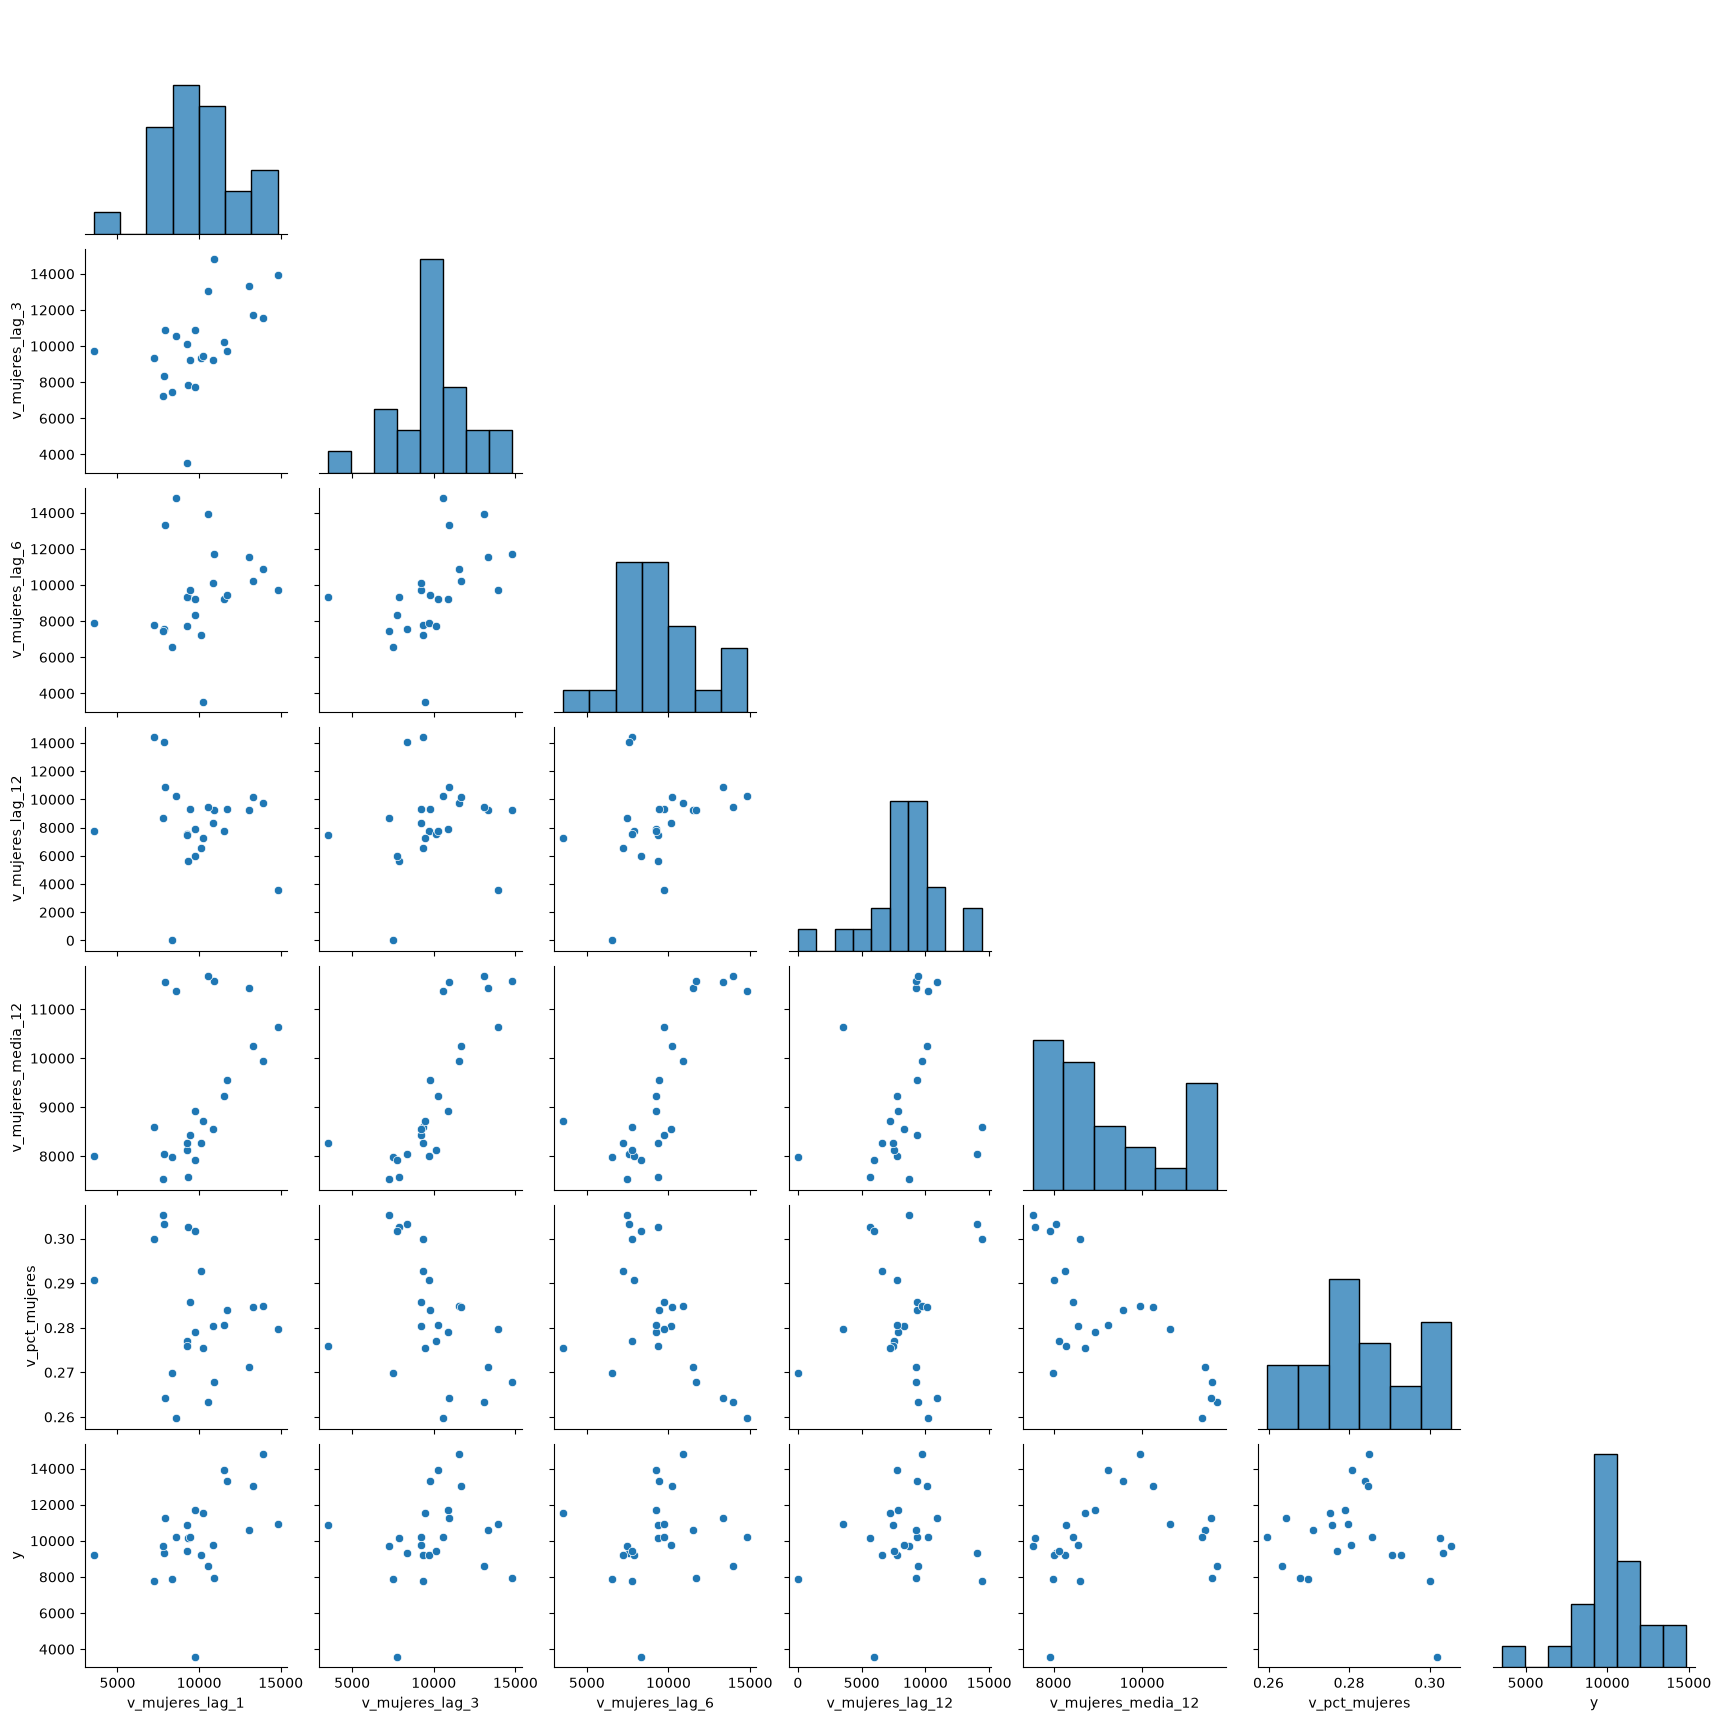

In [65]:
variables_pairplot = [
    "v_mujeres_lag_1",
    "v_mujeres_lag_3",
    "v_mujeres_lag_6",
    "v_mujeres_lag_12",
    "v_mujeres_media_12",
    "v_pct_mujeres",
    "y"
]

datos_pairplot = tad[variables_pairplot].copy()

sns.pairplot(
    datos_pairplot,
    diag_kind="hist",
    corner=True
)

plt.show()

vamos a verificar las variables predigtorias

In [66]:
varc = [
    columna
    for columna in tad.columns
    if columna.startswith("v_") or columna.startswith("c_")
]

X = tad[varc].copy()

print("Variables predictoras:")
print(varc)

Variables predictoras:
['c_mes', 'v_anio', 'v_tendencia', 'v_viajes_mes', 'v_hombres_mes', 'v_pct_mujeres', 'v_duracion_media', 'v_duracion_total', 'v_mujeres_media_12', 'v_mujeres_std_12', 'v_mujeres_min_12', 'v_mujeres_max_12', 'v_mujeres_lag_1', 'v_mujeres_lag_2', 'v_mujeres_lag_3', 'v_mujeres_lag_4', 'v_mujeres_lag_5', 'v_mujeres_lag_6', 'v_mujeres_lag_7', 'v_mujeres_lag_8', 'v_mujeres_lag_9', 'v_mujeres_lag_10', 'v_mujeres_lag_11', 'v_mujeres_lag_12']


In [67]:
X.dtypes

c_mes                    int8
v_anio                  int16
v_tendencia             int64
v_viajes_mes            int64
v_hombres_mes           int64
v_pct_mujeres         float64
v_duracion_media      float32
v_duracion_total      float32
v_mujeres_media_12    float64
v_mujeres_std_12      float64
v_mujeres_min_12      float64
v_mujeres_max_12      float64
v_mujeres_lag_1       float64
v_mujeres_lag_2       float64
v_mujeres_lag_3       float64
v_mujeres_lag_4       float64
v_mujeres_lag_5       float64
v_mujeres_lag_6       float64
v_mujeres_lag_7       float64
v_mujeres_lag_8       float64
v_mujeres_lag_9       float64
v_mujeres_lag_10      float64
v_mujeres_lag_11      float64
v_mujeres_lag_12      float64
dtype: object

ya quedo todo en numerico

In [69]:
%pip install varclushi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 925.6 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 7.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 6.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 2.3 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [70]:
from varclushi import VarClusHi

vc = VarClusHi(
    df=X[varc],
    feat_list=varc
)

vc.varclus()

In [71]:
rs = vc.rsquare.copy()

rs = (
    rs.sort_values(
        by=["Cluster", "RS_Ratio"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

rs["id"] = rs.groupby("Cluster").cumcount() + 1

rs

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio,id
0,0,v_mujeres_media_12,0.968854,0.337211,0.046992,1
1,0,v_tendencia,0.893755,0.468591,0.199931,2
2,0,v_mujeres_lag_5,0.694819,0.141717,0.355571,3
3,0,v_mujeres_lag_6,0.664706,0.143019,0.391250,4
4,0,v_mujeres_lag_4,0.677808,0.191007,0.398262,5
5,0,v_mujeres_lag_7,0.585119,0.129120,0.476393,6
6,0,v_mujeres_lag_8,0.550460,0.113452,0.507068,7
7,0,v_mujeres_lag_3,0.584718,0.303779,0.596480,8
8,0,v_mujeres_min_12,0.395200,0.029768,0.623356,9
9,0,v_mujeres_lag_9,0.471139,0.156521,0.627000,10


vemos como se agruparon

In [72]:
for cluster, grupo in rs.groupby("Cluster"):
    print(f"Cluster {cluster}:")
    print(grupo[["Variable", "RS_Own", "RS_Ratio", "id"]])
    print()

Cluster 0:
              Variable    RS_Own  RS_Ratio  id
0   v_mujeres_media_12  0.968854  0.046992   1
1          v_tendencia  0.893755  0.199931   2
2      v_mujeres_lag_5  0.694819  0.355571   3
3      v_mujeres_lag_6  0.664706  0.391250   4
4      v_mujeres_lag_4  0.677808  0.398262   5
5      v_mujeres_lag_7  0.585119  0.476393   6
6      v_mujeres_lag_8  0.550460  0.507068   7
7      v_mujeres_lag_3  0.584718  0.596480   8
8     v_mujeres_min_12  0.395200  0.623356   9
9      v_mujeres_lag_9  0.471139  0.627000  10
10       v_pct_mujeres  0.548952  0.642032  11
11              v_anio  0.676443  0.668287  12
12    v_mujeres_max_12  0.482684  0.946190  13

Cluster 1:
            Variable    RS_Own  RS_Ratio  id
13  v_duracion_media  0.943365  0.061147   1
14  v_duracion_total  0.906864  0.099113   2
15             c_mes  0.858135  0.152350   3
16  v_mujeres_lag_12  0.290098  0.747821   4

Cluster 2:
           Variable    RS_Own  RS_Ratio  id
17    v_hombres_mes  0.865020  0.17090

In [73]:
varc_reducidas = (
    rs.loc[rs["id"] == 1, "Variable"]
    .tolist()
)

print("Variables seleccionadas:")
print(varc_reducidas)

Variables seleccionadas:
['v_mujeres_media_12', 'v_duracion_media', 'v_hombres_mes', 'v_mujeres_lag_11']


matriz reducida

In [74]:
X_reducida = X[varc_reducidas].copy()

print("Variables originales:", len(varc))
print("Variables seleccionadas:", len(varc_reducidas))

X_reducida.head()

Variables originales: 24
Variables seleccionadas: 4


,v_mujeres_media_12,v_duracion_media,v_hombres_mes,v_mujeres_lag_11
0,7992.666667,-268.142395,19580,14429.0
1,8595.666667,281.826691,18374,14040.0
2,8049.333333,223.537781,17825,8704.0
3,7525.916667,125.002258,21249,5663.0
4,7578.916667,78.284286,22420,6006.0


tad final

In [80]:
tad_final = tad[
    ["UM_periodo"] + varc_reducidas + ["y"]
].copy()

tad_final.head()

,UM_periodo,v_mujeres_media_12,v_duracion_media,v_hombres_mes,v_mujeres_lag_11,y
0,2020-12,7992.666667,-268.142395,19580,14429.0,7873.0
1,2021-01,8595.666667,281.826691,18374,14040.0,7759.0
2,2021-02,8049.333333,223.537781,17825,8704.0,9340.0
3,2021-03,7525.916667,125.002258,21249,5663.0,9725.0
4,2021-04,7578.916667,78.284286,22420,6006.0,10138.0


In [83]:
# 1. Convierte la columna de tipo Period a texto
if "UM_periodo" in tad_final.columns:
    tad_final["UM_periodo"] = tad_final["UM_periodo"].astype(str)

# 2. Asegura que los nombres de las columnas sean texto y sin duplicados
tad_final.columns = tad_final.columns.astype(str)
tad_final = tad_final.loc[:, ~tad_final.columns.duplicated()]

# 3. Exporta a Parquet
tad_final.to_parquet("datos/TAD_ECOBICI_MUJERES_FINAL.parquet", index=False)

ArrowKeyError: A type extension with name pandas.period already defined